# 02 · Preprocesamiento y Feature Engineering
**Proyecto:** Predicción de abandono de clientes – Telco Customer Churn

---
## Objetivo de este notebook
Limpiar los datos, aplicar One-Hot Encoding a variables categóricas y dejar el dataset listo para modelar.

**Imports**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

**Limpieza de datos**

In [2]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


**Eliminar CustomerID al no ser un feature predictivo**

In [4]:
df.drop(columns=['customerID'], inplace=True)

**Convertir cargas totales a valor numérico**

In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

**Imputar valores nulos en TotalCharges**

In [6]:
df[df['TotalCharges'].isna()][['tenure','MonthlyCharges','TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [7]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

**Convertir variable objetivo (Churn) a variable numérica**

In [8]:
churn = {'Yes': 1, 'No': 0}
df['Churn'] = df['Churn'].replace(churn)

/tmp/ipykernel_52875/2441981691.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn'] = df['Churn'].replace(churn)


**Separación de columnas**

In [9]:
target = 'Churn'
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
binary_cols = ['SeniorCitizen']

categorical_cols = [
    col for col in df.columns
    if col not in numeric_cols + binary_cols + [target]
]

print(f'Numéricas: {numeric_cols}')
print(f'Binarias:  {binary_cols}')
print(f'Categóricas ({len(categorical_cols)}): {categorical_cols}')

Numéricas: ['tenure', 'MonthlyCharges', 'TotalCharges']
Binarias:  ['SeniorCitizen']
Categóricas (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


**Separación X e Y**

In [10]:
X = df.drop(columns=['Churn'])
y = df['Churn']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Proporción de Churn en y: {y.mean()*100:.1f}%')

X shape: (7043, 19)
y shape: (7043,)
Proporción de Churn en y: 26.5%


**One-Hot Encoding**
Conversión de variables categóricas a numéricas. Se usa drop_first=True para evitar la dummy variable trap (multicolinealidad perfecta entre columnas generadas de la misma variable).

In [11]:
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [12]:
new_cols = [c for c in X_encoded.columns if c not in X.columns]
print(new_cols)

['gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [13]:
X_encoded.shape

(7043, 30)

In [14]:
X_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


**División del dataset en train, validation y test**

In [15]:
# Primero separar test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Luego separar val del resto
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

In [16]:
print(f'Train: {X_train.shape[0]} muestras — Churn: {y_train.mean()*100:.1f}%')
print(f'Val:   {X_val.shape[0]} muestras — Churn: {y_val.mean()*100:.1f}%')
print(f'Test:  {X_test.shape[0]} muestras — Churn: {y_test.mean()*100:.1f}%')
print(f'\nTotal: {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]} muestras')

Train: 4225 muestras — Churn: 26.5%
Val:   1409 muestras — Churn: 26.5%
Test:  1409 muestras — Churn: 26.5%

Total: 7043 muestras


**Guardar datasets procesados**

In [17]:
X_train.to_csv('../data/processed/X_train.csv', index=False)
X_val.to_csv('../data/processed/X_val.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_val.to_csv('../data/processed/y_val.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)


El escalado de variables numéricas se realizará en el notebook siguiente, ya que su necesidad depende del algoritmo utilizado.

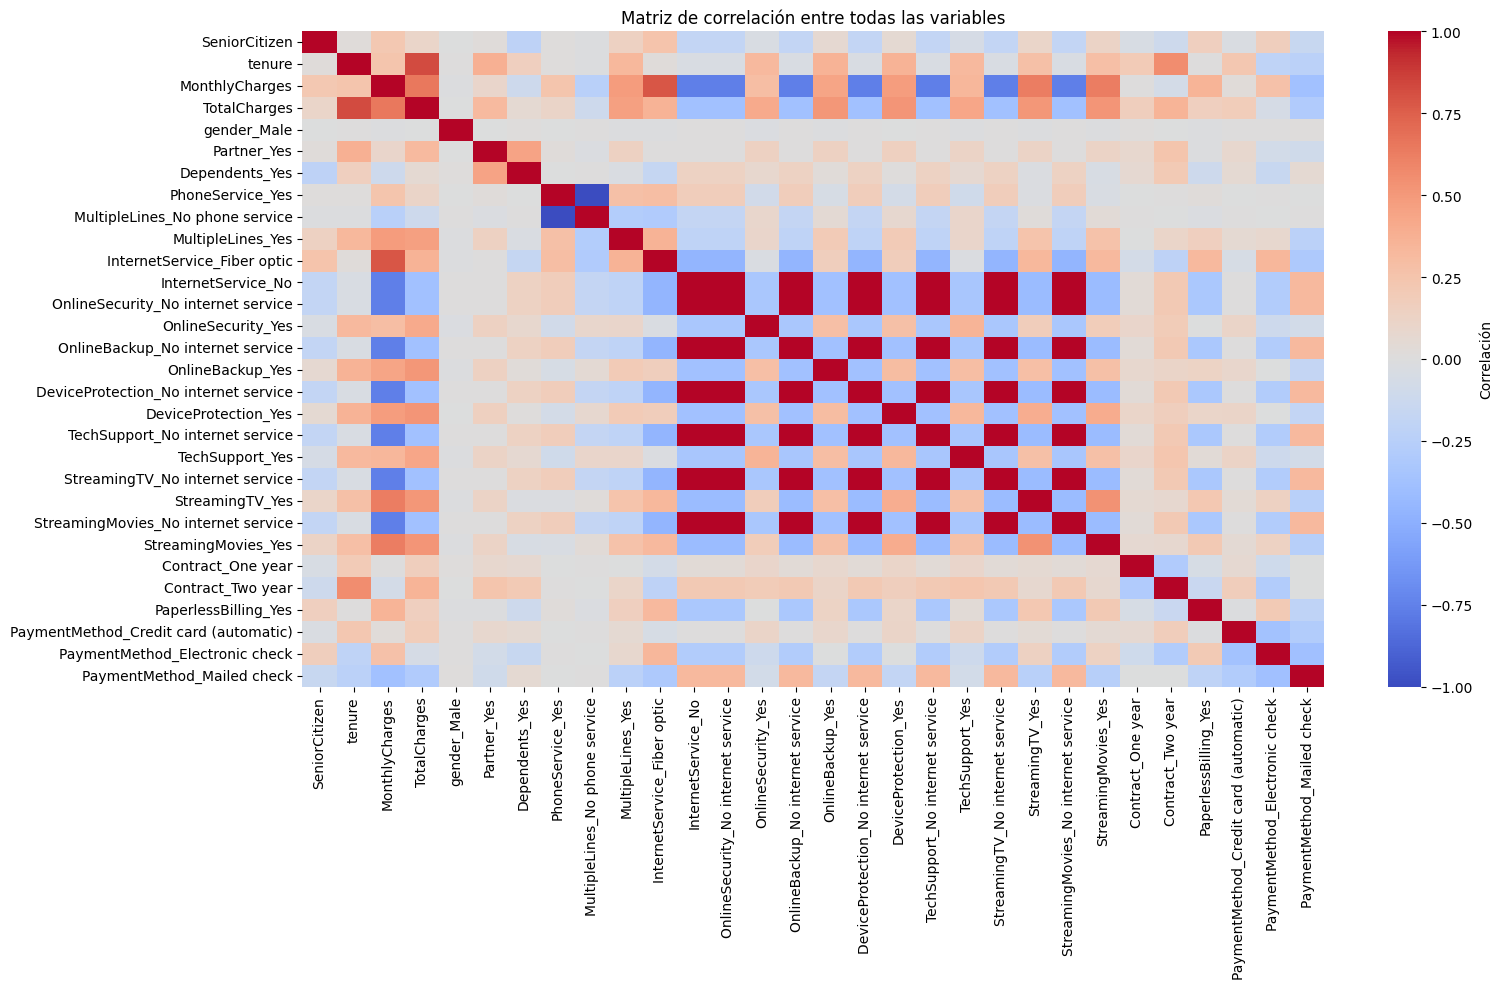

In [19]:
plt.figure(figsize=(16, 10))
correlation_matrix = X_encoded.corr()
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, annot=False, cbar_kws={'label': 'Correlación'})
plt.title('Matriz de correlación entre todas las variables')
plt.tight_layout()
plt.show()